
# Week X / Text Detox Steering Case Study

## What it does
- downloads **Civil Comments** and builds a **binary toxicity steering** training set
- optionally downloads **ParaDetox** for paired detox evaluation
- encodes text with a pretrained sentence encoder
- learns **global** and **local** detox directions in representation space
- generates rewrite candidates for toxic inputs and compares **fixed alpha** vs **automatic alpha\***
- saves CSV summaries, preview examples, plots, and a short memo in a timestamped run directory

## Main question
Can we make text **less toxic** by moving along a **global** or **local** linear direction in a pretrained language representation space, while preserving semantic meaning as much as possible?



---
Stage X: Text detox steering in pretrained representation spaces  
---------------------------------------------------------------
**Why:**  
Toxicity is a human-interpretable text attribute, so it is a good setting for testing whether steering directions are truly semantic or only produce superficial wording changes.

**What:**  
We use **Civil Comments** to learn a direction from toxic to non-toxic text, then compare **global** versus **cluster-local** steering. We use **ParaDetox** as an optional paired benchmark to see how our generated rewrites compare with human-written detox references.

**How:**  
1. build embeddings for toxic / non-toxic examples,  
2. estimate detox directions,  
3. generate candidate rewrites for toxic inputs,  
4. choose the best rewrite under toxicity reduction + semantic preservation + target-direction agreement,  
5. compare fixed alpha with automatic alpha*.

**Outputs:**
- `config.json`
- `cluster_stats.csv`
- `results_text_detox_by_alpha.csv`
- `results_text_detox_compare.csv`
- `results_text_detox_summary.csv`
- `preview_text_detox.csv`
- `memo_text_detox.md`
- plots in `plots/`


In [21]:
%pip install -q pandas numpy matplotlib scikit-learn torch sentence-transformers transformers datasets accelerate tqdm

Note: you may need to restart the kernel to use updated packages.


In [22]:

import os
import json
import math
import time
import random
import warnings
from pathlib import Path
from typing import Any, Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn.functional as F

from tqdm.auto import tqdm
from datasets import load_dataset
from sentence_transformers import SentenceTransformer
from transformers import (
    AutoModelForCausalLM,
    AutoModelForSeq2SeqLM,
    AutoTokenizer,
    pipeline,
)
from sklearn.cluster import MiniBatchKMeans
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from IPython.display import display

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message=".*clean_up_tokenization_spaces.*")


In [23]:

# Fill these paths / knobs manually if needed.
cfg: Dict[str, Any] = {
    "seed": 42,
    "device": "cuda",

    "run": {
        "root": "./runs",
        "tag": "week12_text_detox_steering",
    },

    "data": {
        "civil_comments_dataset": "google/civil_comments",
        "paradetox_dataset": "s-nlp/paradetox",
        "use_paradetox_eval": True,

        "text_col": "text",
        "toxicity_col": "toxicity",
        "toxic_min": 0.50,
        "clean_max": 0.10,
        "min_text_chars": 8,

        # We first sample a raw pool, then keep balanced clean/toxic examples.
        "civil_raw_pool_train": 50000,
        "civil_raw_pool_eval": 12000,
        "train_max_rows": 12000,
        "eval_max_rows": 300,
        "paradetox_eval_max_rows": 150,
    },

    "models": {
        "sentence_encoder_name": "all-mpnet-base-v2",
        "toxicity_model_name": "unitary/toxic-bert",
        "rewriter_model_name": "google/flan-t5-base",
        "fluency_model_name": "distilgpt2",
    },

    "steering": {
        "direction_key": "probe",      # "probe" or "mean_diff"
        "num_clusters": 8,
        "min_cluster_class_count": 12,
        "alpha_grid": [0.0, 0.5, 1.0, 1.5, 2.0],
        "fixed_alpha": 1.0,
    },

    "generation": {
        "num_return_sequences": 4,
        "num_beams": 4,
        "do_sample": True,
        "temperature": 0.9,
        "max_new_tokens": 64,
        "batch_size": 16,
    },

    "selection": {
        "min_semantic_similarity": 0.72,
        "min_toxicity_drop": 0.12,
        "weights": {
            "target": 0.35,
            "detox": 0.35,
            "semantic": 0.25,
            "surface": 0.05,
            "fluency": 0.00,   # keep 0.00 for a lighter run; raise if you enable fluency scoring
        },
    },

    "fluency": {
        "enabled": False,
        "max_length": 128,
        "batch_size": 8,
    },

    "preview": {
        "top_k": 20,
    },
}

cfg


{'seed': 42,
 'device': 'cuda',
 'run': {'root': './runs', 'tag': 'week12_text_detox_steering'},
 'data': {'civil_comments_dataset': 'google/civil_comments',
  'paradetox_dataset': 's-nlp/paradetox',
  'use_paradetox_eval': True,
  'text_col': 'text',
  'toxicity_col': 'toxicity',
  'toxic_min': 0.5,
  'clean_max': 0.1,
  'min_text_chars': 8,
  'civil_raw_pool_train': 50000,
  'civil_raw_pool_eval': 12000,
  'train_max_rows': 12000,
  'eval_max_rows': 300,
  'paradetox_eval_max_rows': 150},
 'models': {'sentence_encoder_name': 'all-mpnet-base-v2',
  'toxicity_model_name': 'unitary/toxic-bert',
  'rewriter_model_name': 'google/flan-t5-base',
  'fluency_model_name': 'distilgpt2'},
 'steering': {'direction_key': 'probe',
  'num_clusters': 8,
  'min_cluster_class_count': 12,
  'alpha_grid': [0.0, 0.5, 1.0, 1.5, 2.0],
  'fixed_alpha': 1.0},
 'generation': {'num_return_sequences': 4,
  'num_beams': 4,
  'do_sample': True,
  'temperature': 0.9,
  'max_new_tokens': 64,
  'batch_size': 16},
 's

In [24]:

# ------------------------ helpers ------------------------
def get_device(name: str) -> torch.device:
    if name == "cuda" and torch.cuda.is_available():
        return torch.device("cuda")
    return torch.device("cpu")


def pipeline_device_index(device: torch.device) -> int:
    return 0 if device.type == "cuda" else -1


def seed_everything(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


def ensure_dir(path: Path) -> Path:
    path.mkdir(parents=True, exist_ok=True)
    return path


def now_tag() -> str:
    return time.strftime("%Y%m%d_%H%M%S")


def make_run_dir(cfg: Dict[str, Any]) -> Path:
    root = ensure_dir(Path(cfg["run"]["root"]))
    run_dir = ensure_dir(root / f"{now_tag()}_{cfg['run']['tag']}")
    ensure_dir(run_dir / "plots")
    return run_dir


def save_json(path: Path, obj: Dict[str, Any]) -> None:
    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, indent=2, ensure_ascii=False)


def safe_text(x: Any) -> str:
    return " ".join(str(x).split())


def unique_keep_order(items: List[str]) -> List[str]:
    seen = set()
    out: List[str] = []
    for item in items:
        if item not in seen:
            seen.add(item)
            out.append(item)
    return out


def normalize_vec(v: np.ndarray, eps: float = 1e-12) -> np.ndarray:
    n = float(np.linalg.norm(v))
    if n < eps:
        return v.copy()
    return v / n


def normalize_rows(x: np.ndarray, eps: float = 1e-12) -> np.ndarray:
    denom = np.linalg.norm(x, axis=1, keepdims=True)
    denom = np.maximum(denom, eps)
    return x / denom


def cosine_rowwise(a: np.ndarray, b: np.ndarray) -> np.ndarray:
    return np.sum(a * b, axis=1)


def pick_first_existing(columns: List[str], candidates: List[str]) -> Optional[str]:
    lower_to_real = {c.lower(): c for c in columns}
    for cand in candidates:
        if cand.lower() in lower_to_real:
            return lower_to_real[cand.lower()]
    return None


def surface_penalty(text: str, ref_text: str) -> float:
    toks = text.lower().split()
    ref_toks = ref_text.lower().split()
    if len(toks) == 0:
        return 1.0
    unique_ratio = len(set(toks)) / max(1, len(toks))
    rep_pen = max(0.0, 0.85 - unique_ratio)
    len_ratio = len(toks) / max(1, len(ref_toks))
    len_pen = max(0.0, abs(len_ratio - 1.0) - 0.35)
    short_pen = 0.25 if len(toks) < 3 else 0.0
    return float(rep_pen + len_pen + short_pen)


In [25]:
def load_paradetox_eval_frame(cfg: Dict[str, Any]) -> pd.DataFrame:
    if not cfg["data"]["use_paradetox_eval"]:
        return pd.DataFrame(columns=["text", "reference_text", "label", "source", "sample_id"])

    dataset_name = cfg["data"]["paradetox_dataset"]
    try:
        ds_all = load_dataset(dataset_name)
    except Exception:
        ds_all = load_dataset(dataset_name, "en")

    split_name = "train" if "train" in ds_all else list(ds_all.keys())[0]
    ds = ds_all[split_name]
    take_n = min(cfg["data"]["paradetox_eval_max_rows"], len(ds))
    df = ds.shuffle(seed=cfg["seed"] + 3).select(range(take_n)).to_pandas()

    src_col = pick_first_existing(list(df.columns), [
        "en_toxic_comment",
        "toxic",
        "toxic_sentence",
        "toxic_text",
        "toxic_comment",
        "source",
        "input",
        "text",
        "sentence",
        "source_text",
    ])
    tgt_col = pick_first_existing(list(df.columns), [
        "en_neutral_comment",
        "neutral",
        "neutral_text",
        "neutral_comment",
        "detoxified",
        "reference",
        "target",
        "rewritten",
        "non_toxic",
        "neutral_sentence",
        "ref_text",
    ])

    if src_col is None:
        raise ValueError(
            f"Could not infer source toxic text column from ParaDetox columns: {list(df.columns)}"
        )

    out = pd.DataFrame({"text": df[src_col].map(safe_text)})

    if tgt_col is not None:
        out["reference_text"] = df[tgt_col].map(safe_text)
    else:
        out["reference_text"] = ""

    out = out[out["text"].str.len() >= cfg["data"]["min_text_chars"]].reset_index(drop=True)
    out["label"] = 1
    out["source"] = "paradetox_eval"
    out["sample_id"] = [f"paradetox_{i:05d}" for i in range(len(out))]
    return out

In [26]:
# ------------------------ data utilities ------------------------
def _filter_text_frame(df: pd.DataFrame, text_col: str, min_text_chars: int) -> pd.DataFrame:
    out = df.copy()
    out[text_col] = out[text_col].map(safe_text)
    out = out[out[text_col].str.len() >= min_text_chars].reset_index(drop=True)
    return out


def _balanced_binary_from_scores(
    df: pd.DataFrame,
    text_col: str,
    score_col: str,
    toxic_min: float,
    clean_max: float,
    max_rows: int,
    seed: int,
) -> pd.DataFrame:
    work = df.copy()
    toxic_mask = work[score_col] >= toxic_min
    clean_mask = work[score_col] <= clean_max
    work = work[toxic_mask | clean_mask].copy()
    work["label"] = np.where(work[score_col] >= toxic_min, 1, 0)

    toxic_df = work[work["label"] == 1]
    clean_df = work[work["label"] == 0]
    n_per_class = max(1, max_rows // 2)
    toxic_take = toxic_df.sample(n=min(len(toxic_df), n_per_class), random_state=seed)
    clean_take = clean_df.sample(n=min(len(clean_df), n_per_class), random_state=seed)
    out = pd.concat([toxic_take, clean_take], axis=0).sample(frac=1.0, random_state=seed).reset_index(drop=True)
    return out[[text_col, score_col, "label"]].rename(columns={text_col: "text", score_col: "toxicity"})


def _toxic_only_from_scores(
    df: pd.DataFrame,
    text_col: str,
    score_col: str,
    toxic_min: float,
    max_rows: int,
    seed: int,
) -> pd.DataFrame:
    work = df.copy()
    work = work[work[score_col] >= toxic_min].copy()
    if len(work) == 0:
        raise ValueError("No toxic examples left after thresholding. Lower toxic_min.")
    if len(work) > max_rows:
        work = work.sample(n=max_rows, random_state=seed)
    work["label"] = 1
    return work[[text_col, score_col, "label"]].rename(columns={text_col: "text", score_col: "toxicity"}).reset_index(drop=True)


def _sample_split_to_pandas(ds_split, raw_pool: int, seed: int) -> pd.DataFrame:
    take_n = min(raw_pool, len(ds_split))
    ds_small = ds_split.shuffle(seed=seed).select(range(take_n))
    return ds_small.to_pandas()


def load_civil_comments_frames(cfg: Dict[str, Any]) -> Tuple[pd.DataFrame, pd.DataFrame, Dict[str, Any]]:
    ds_all = load_dataset(cfg["data"]["civil_comments_dataset"])
    split_names = list(ds_all.keys())
    train_name = "train" if "train" in split_names else split_names[0]
    eval_name = "validation" if "validation" in split_names else ("test" if "test" in split_names else train_name)

    train_df_raw = _sample_split_to_pandas(ds_all[train_name], cfg["data"]["civil_raw_pool_train"], cfg["seed"])
    eval_df_raw = _sample_split_to_pandas(ds_all[eval_name], cfg["data"]["civil_raw_pool_eval"], cfg["seed"] + 1)

    text_col = cfg["data"]["text_col"]
    tox_col = cfg["data"]["toxicity_col"]
    train_df_raw = _filter_text_frame(train_df_raw[[text_col, tox_col]].dropna(), text_col, cfg["data"]["min_text_chars"])
    eval_df_raw = _filter_text_frame(eval_df_raw[[text_col, tox_col]].dropna(), text_col, cfg["data"]["min_text_chars"])

    train_df = _balanced_binary_from_scores(
        train_df_raw,
        text_col=text_col,
        score_col=tox_col,
        toxic_min=cfg["data"]["toxic_min"],
        clean_max=cfg["data"]["clean_max"],
        max_rows=cfg["data"]["train_max_rows"],
        seed=cfg["seed"],
    )
    eval_df = _toxic_only_from_scores(
        eval_df_raw,
        text_col=text_col,
        score_col=tox_col,
        toxic_min=cfg["data"]["toxic_min"],
        max_rows=cfg["data"]["eval_max_rows"],
        seed=cfg["seed"] + 1,
    )

    train_df["source"] = "civil_comments_train"
    train_df["sample_id"] = [f"civil_train_{i:05d}" for i in range(len(train_df))]
    eval_df["source"] = "civil_comments_eval"
    eval_df["sample_id"] = [f"civil_eval_{i:05d}" for i in range(len(eval_df))]

    info = {
        "train_split": train_name,
        "eval_split": eval_name,
        "train_rows": int(len(train_df)),
        "eval_rows": int(len(eval_df)),
        "train_raw_pool": int(len(train_df_raw)),
        "eval_raw_pool": int(len(eval_df_raw)),
    }
    return train_df.reset_index(drop=True), eval_df.reset_index(drop=True), info


def load_paradetox_eval_frame(cfg: Dict[str, Any]) -> pd.DataFrame:
    if not cfg["data"]["use_paradetox_eval"]:
        return pd.DataFrame(columns=["text", "reference_text", "label", "source", "sample_id"])

    dataset_name = cfg["data"]["paradetox_dataset"]
    try:
        ds_all = load_dataset(dataset_name)
    except Exception:
        ds_all = load_dataset(dataset_name, "en")

    split_name = "train" if "train" in ds_all else list(ds_all.keys())[0]
    ds = ds_all[split_name]
    take_n = min(cfg["data"]["paradetox_eval_max_rows"], len(ds))
    df = ds.shuffle(seed=cfg["seed"] + 3).select(range(take_n)).to_pandas()

    src_col = pick_first_existing(list(df.columns), [
        "en_toxic_comment",
        "toxic",
        "toxic_sentence",
        "toxic_text",
        "toxic_comment",
        "source",
        "input",
        "text",
        "sentence",
        "source_text",
    ])
    tgt_col = pick_first_existing(list(df.columns), [
        "en_neutral_comment",
        "neutral",
        "neutral_text",
        "neutral_comment",
        "detoxified",
        "reference",
        "target",
        "rewritten",
        "non_toxic",
        "neutral_sentence",
        "ref_text",
    ])

    if src_col is None:
        raise ValueError(
            f"Could not infer source toxic text column from ParaDetox columns: {list(df.columns)}"
        )

    out = pd.DataFrame({"text": df[src_col].map(safe_text)})

    if tgt_col is not None:
        out["reference_text"] = df[tgt_col].map(safe_text)
    else:
        out["reference_text"] = ""

    out = out[out["text"].str.len() >= cfg["data"]["min_text_chars"]].reset_index(drop=True)
    out["label"] = 1
    out["source"] = "paradetox_eval"
    out["sample_id"] = [f"paradetox_{i:05d}" for i in range(len(out))]
    return out

In [27]:

# ------------------------ models + scorers ------------------------
def load_sentence_encoder(name: str, device: torch.device) -> SentenceTransformer:
    model = SentenceTransformer(name, device=str(device))
    return model


def encode_texts(model: SentenceTransformer, texts: List[str], batch_size: int = 64) -> np.ndarray:
    emb = model.encode(
        texts,
        batch_size=batch_size,
        show_progress_bar=len(texts) >= 128,
        convert_to_numpy=True,
        normalize_embeddings=True,
    )
    return emb.astype(np.float32)


def load_toxicity_scorer(model_name: str, device: torch.device):
    return pipeline(
        task="text-classification",
        model=model_name,
        tokenizer=model_name,
        device=pipeline_device_index(device),
        top_k=None,
        truncation=True,
    )


def _extract_toxic_score(raw_output: Any) -> float:
    items = raw_output if isinstance(raw_output, list) else [raw_output]
    label_to_score = {str(d["label"]).lower(): float(d["score"]) for d in items}
    for key in ["toxic", "toxicity", "label_1", "1"]:
        if key in label_to_score:
            return label_to_score[key]
    if len(items) == 1:
        label = str(items[0]["label"]).lower()
        score = float(items[0]["score"])
        if any(tok in label for tok in ["toxic", "1"]):
            return score
        return 1.0 - score
    return max(label_to_score.values())


def score_toxicity_texts(scorer, texts: List[str], batch_size: int = 16) -> np.ndarray:
    scores: List[float] = []
    for i in tqdm(range(0, len(texts), batch_size), desc="toxicity", leave=False):
        batch = texts[i:i + batch_size]
        outputs = scorer(batch, batch_size=batch_size)
        scores.extend([_extract_toxic_score(o) for o in outputs])
    return np.asarray(scores, dtype=np.float32)


def load_rewriter(model_name: str, device: torch.device):
    tok = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForSeq2SeqLM.from_pretrained(model_name)
    model.to(device)
    model.eval()
    return {
        "tokenizer": tok,
        "model": model,
        "device": device,
    }


@torch.no_grad()
def run_rewriter(
    rewriter,
    prompt: str,
    max_new_tokens: int,
    num_return_sequences: int,
    num_beams: int,
    do_sample: bool,
    temperature: float,
):
    tok = rewriter["tokenizer"]
    model = rewriter["model"]
    device = rewriter["device"]

    enc = tok(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=256,
    )
    enc = {k: v.to(device) for k, v in enc.items()}

    gen_kwargs = {
        "max_new_tokens": max_new_tokens,
        "num_return_sequences": num_return_sequences,
        "num_beams": max(num_beams, num_return_sequences),
        "do_sample": do_sample,
    }
    if do_sample:
        gen_kwargs["temperature"] = temperature

    out_ids = model.generate(**enc, **gen_kwargs)
    texts = tok.batch_decode(out_ids, skip_special_tokens=True)

    return [{"generated_text": " ".join(str(t).split())} for t in texts]



def alpha_to_detox_instruction(alpha: float) -> str:
    if alpha <= 0.0:
        return "Keep the meaning and make only minimal edits."
    if alpha <= 0.5:
        return "Make the text slightly less toxic and more neutral while preserving the meaning."
    if alpha <= 1.0:
        return "Rewrite the text to be clearly non-toxic and respectful while preserving the meaning."
    if alpha <= 1.5:
        return "Rewrite the text to be calm, respectful, and professional while preserving the meaning."
    return "Rewrite the text to be fully non-toxic, calm, and constructive while preserving the meaning as much as possible."


def build_detox_prompt(text: str, alpha: float) -> str:
    instruction = alpha_to_detox_instruction(alpha)
    return (
        "You are rewriting a toxic sentence into a less toxic version. "
        "Do not change the core meaning more than necessary. "
        f"{instruction}\n"
        f"Text: {text}\n"
        "Rewrite:"
    )


def generate_candidate_bank(rewriter, text: str, alpha_grid: List[float], cfg: Dict[str, Any]) -> List[Dict[str, Any]]:
    candidates: List[Dict[str, Any]] = [{
        "candidate_text": safe_text(text),
        "candidate_source": "original",
        "prompt_alpha": 0.0,
    }]

    unique_alphas = sorted({float(a) for a in alpha_grid if a > 0.0})
    for alpha in unique_alphas:
        prompt = build_detox_prompt(text, alpha)
        outputs = run_rewriter(
            rewriter=rewriter,
            prompt=prompt,
            max_new_tokens=cfg["generation"]["max_new_tokens"],
            num_return_sequences=cfg["generation"]["num_return_sequences"],
            num_beams=cfg["generation"]["num_beams"],
            do_sample=cfg["generation"]["do_sample"],
            temperature=cfg["generation"]["temperature"],
        )
        for out in outputs:
            cand = safe_text(out["generated_text"])
            if cand:
                candidates.append({
                    "candidate_text": cand,
                    "candidate_source": "rewriter",
                    "prompt_alpha": float(alpha),
                })

    uniq_texts = unique_keep_order([c["candidate_text"] for c in candidates])
    text_to_meta = {}
    for c in candidates:
        text_to_meta.setdefault(c["candidate_text"], c)
    return [text_to_meta[t] for t in uniq_texts]


def load_fluency_lm(model_name: str, device: torch.device):
    tok = AutoTokenizer.from_pretrained(model_name)
    if tok.pad_token is None:
        tok.pad_token = tok.eos_token
    lm = AutoModelForCausalLM.from_pretrained(model_name)
    lm.to(device)
    lm.eval()
    return tok, lm


@torch.no_grad()
def score_fluency_ppl(texts: List[str], tok, lm, device: torch.device, max_length: int = 128) -> np.ndarray:
    ppls: List[float] = []
    for text in tqdm(texts, desc="fluency", leave=False):
        enc = tok(text, return_tensors="pt", truncation=True, max_length=max_length)
        enc = {k: v.to(device) for k, v in enc.items()}
        out = lm(**enc, labels=enc["input_ids"])
        ppl = float(torch.exp(out.loss).detach().cpu().item())
        ppls.append(ppl)
    return np.asarray(ppls, dtype=np.float32)


In [28]:

# ------------------------ steering directions ------------------------
def fit_global_directions(x_train: np.ndarray, y_train: np.ndarray, seed: int) -> Dict[str, Any]:
    clean_mu = x_train[y_train == 0].mean(axis=0)
    toxic_mu = x_train[y_train == 1].mean(axis=0)
    mean_diff = normalize_vec(clean_mu - toxic_mu)

    probe = LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=seed,
    )
    probe.fit(x_train, y_train)
    toxic_auc = roc_auc_score(y_train, probe.predict_proba(x_train)[:, 1])
    probe_dir = normalize_vec(-probe.coef_[0].astype(np.float32))

    return {
        "mean_diff": mean_diff.astype(np.float32),
        "probe": probe_dir.astype(np.float32),
        "probe_model": probe,
        "probe_train_auc": float(toxic_auc),
    }


def fit_local_directions(
    x_train: np.ndarray,
    y_train: np.ndarray,
    global_dirs: Dict[str, Any],
    num_clusters: int,
    min_cluster_class_count: int,
    seed: int,
) -> Tuple[MiniBatchKMeans, Dict[int, Dict[str, np.ndarray]], pd.DataFrame]:
    kmeans = MiniBatchKMeans(
        n_clusters=num_clusters,
        random_state=seed,
        batch_size=2048,
        n_init=10,
    )
    cluster_ids = kmeans.fit_predict(x_train)

    local_dirs: Dict[int, Dict[str, np.ndarray]] = {}
    stats: List[Dict[str, Any]] = []

    for c in range(num_clusters):
        idx = np.where(cluster_ids == c)[0]
        x_c = x_train[idx]
        y_c = y_train[idx]
        n_total = int(len(idx))
        n_clean = int((y_c == 0).sum())
        n_toxic = int((y_c == 1).sum())
        fallback = False

        mean_diff = global_dirs["mean_diff"]
        probe_dir = global_dirs["probe"]
        probe_auc = np.nan

        if n_clean >= min_cluster_class_count and n_toxic >= min_cluster_class_count:
            clean_mu = x_c[y_c == 0].mean(axis=0)
            toxic_mu = x_c[y_c == 1].mean(axis=0)
            mean_diff = normalize_vec(clean_mu - toxic_mu).astype(np.float32)

            probe_c = LogisticRegression(
                max_iter=1000,
                class_weight="balanced",
                random_state=seed,
            )
            probe_c.fit(x_c, y_c)
            probe_dir = normalize_vec(-probe_c.coef_[0].astype(np.float32))
            probe_auc = float(roc_auc_score(y_c, probe_c.predict_proba(x_c)[:, 1]))
        else:
            fallback = True

        local_dirs[c] = {
            "mean_diff": mean_diff,
            "probe": probe_dir,
        }
        stats.append({
            "cluster_id": c,
            "size": n_total,
            "n_clean": n_clean,
            "n_toxic": n_toxic,
            "fallback_to_global": int(fallback),
            "probe_train_auc": probe_auc,
        })

    cluster_stats = pd.DataFrame(stats).sort_values("cluster_id").reset_index(drop=True)
    return kmeans, local_dirs, cluster_stats


def get_direction_for_sample(
    z: np.ndarray,
    mode: str,
    direction_key: str,
    kmeans: MiniBatchKMeans,
    global_dirs: Dict[str, Any],
    local_dirs: Dict[int, Dict[str, np.ndarray]],
) -> Tuple[np.ndarray, int]:
    cluster_id = int(kmeans.predict(z.reshape(1, -1))[0])
    if mode == "global":
        return global_dirs[direction_key], cluster_id
    if mode == "local":
        return local_dirs[cluster_id][direction_key], cluster_id
    raise ValueError(f"Unknown mode: {mode}")


In [29]:

# ------------------------ evaluation ------------------------
def score_candidate_bank(
    text: str,
    candidate_bank: List[Dict[str, Any]],
    encoder,
    toxicity_scorer,
    cfg: Dict[str, Any],
    fluency_bundle: Optional[Tuple[Any, Any, torch.device]] = None,
) -> pd.DataFrame:
    cand_texts = [c["candidate_text"] for c in candidate_bank]
    emb = encode_texts(encoder, cand_texts, batch_size=cfg["generation"]["batch_size"])
    tox = score_toxicity_texts(toxicity_scorer, cand_texts, batch_size=cfg["generation"]["batch_size"])
    z0 = encode_texts(encoder, [text], batch_size=1)[0]
    sim = cosine_rowwise(emb, np.repeat(z0.reshape(1, -1), len(cand_texts), axis=0))
    surface = np.asarray([surface_penalty(t, text) for t in cand_texts], dtype=np.float32)

    ppl = np.full(len(cand_texts), np.nan, dtype=np.float32)
    if fluency_bundle is not None:
        tok, lm, device = fluency_bundle
        ppl = score_fluency_ppl(cand_texts, tok, lm, device=device, max_length=cfg["fluency"]["max_length"])

    rows = []
    for i, meta in enumerate(candidate_bank):
        rows.append({
            "candidate_text": meta["candidate_text"],
            "candidate_source": meta["candidate_source"],
            "prompt_alpha": float(meta["prompt_alpha"]),
            "toxicity": float(tox[i]),
            "semantic_similarity": float(sim[i]),
            "surface_penalty": float(surface[i]),
            "fluency_ppl": float(ppl[i]) if not np.isnan(ppl[i]) else np.nan,
            "emb_idx": i,
        })
    return pd.DataFrame(rows), z0, emb


def _objective_values(
    target_sim: np.ndarray,
    tox_drop: np.ndarray,
    sem_sim: np.ndarray,
    surface_pen: np.ndarray,
    fluency_ppl: np.ndarray,
    weights: Dict[str, float],
) -> np.ndarray:
    fluency_term = np.zeros_like(target_sim, dtype=np.float32)
    if np.isfinite(fluency_ppl).any() and weights.get("fluency", 0.0) > 0:
        finite = np.where(np.isfinite(fluency_ppl), fluency_ppl, np.nan)
        med = np.nanmedian(finite)
        mad = np.nanmedian(np.abs(finite - med)) + 1e-6
        scaled = np.where(np.isfinite(finite), (finite - med) / mad, 0.0)
        fluency_term = scaled.astype(np.float32)

    obj = (
        weights["target"] * target_sim
        + weights["detox"] * tox_drop
        + weights["semantic"] * sem_sim
        - weights["surface"] * surface_pen
        - weights.get("fluency", 0.0) * fluency_term
    )
    return obj.astype(np.float32)


def evaluate_one_sample(
    row: pd.Series,
    mode: str,
    direction_key: str,
    encoder,
    toxicity_scorer,
    rewriter,
    kmeans,
    global_dirs,
    local_dirs,
    cfg: Dict[str, Any],
    fluency_bundle: Optional[Tuple[Any, Any, torch.device]] = None,
) -> Tuple[pd.DataFrame, Dict[str, Any], Dict[str, Any]]:
    text = safe_text(row["text"])
    sample_id = row["sample_id"]
    source = row.get("source", "unknown")
    reference_text = safe_text(row.get("reference_text", "")) if "reference_text" in row else ""

    candidate_bank = generate_candidate_bank(rewriter, text, cfg["steering"]["alpha_grid"], cfg)
    cand_df, z0, cand_emb = score_candidate_bank(
        text=text,
        candidate_bank=candidate_bank,
        encoder=encoder,
        toxicity_scorer=toxicity_scorer,
        cfg=cfg,
        fluency_bundle=fluency_bundle,
    )

    tox0 = float(score_toxicity_texts(toxicity_scorer, [text], batch_size=1)[0])
    direction, cluster_id = get_direction_for_sample(
        z=z0,
        mode=mode,
        direction_key=direction_key,
        kmeans=kmeans,
        global_dirs=global_dirs,
        local_dirs=local_dirs,
    )

    weights = cfg["selection"]["weights"]
    per_alpha_rows: List[Dict[str, Any]] = []

    for alpha in cfg["steering"]["alpha_grid"]:
        target = normalize_vec(z0 + float(alpha) * direction)
        target_sim = cosine_rowwise(cand_emb, np.repeat(target.reshape(1, -1), len(cand_df), axis=0))
        tox_drop = tox0 - cand_df["toxicity"].to_numpy(dtype=np.float32)
        sem_sim = cand_df["semantic_similarity"].to_numpy(dtype=np.float32)
        surface = cand_df["surface_penalty"].to_numpy(dtype=np.float32)
        ppl = cand_df["fluency_ppl"].to_numpy(dtype=np.float32)
        objective = _objective_values(target_sim, tox_drop, sem_sim, surface, ppl, weights)
        feasible = (
            (sem_sim >= cfg["selection"]["min_semantic_similarity"])
            & (tox_drop >= cfg["selection"]["min_toxicity_drop"])
        )

        choose_from = np.where(feasible)[0] if feasible.any() else np.arange(len(cand_df))
        best_rel = int(choose_from[np.argmax(objective[choose_from])])
        best = cand_df.iloc[best_rel].to_dict()

        per_alpha_rows.append({
            "sample_id": sample_id,
            "source": source,
            "mode": mode,
            "direction_key": direction_key,
            "cluster_id": cluster_id,
            "alpha": float(alpha),
            "selected_text": best["candidate_text"],
            "candidate_source": best["candidate_source"],
            "prompt_alpha": float(best["prompt_alpha"]),
            "toxicity_before": tox0,
            "toxicity_after": float(best["toxicity"]),
            "toxicity_drop": float(tox0 - best["toxicity"]),
            "semantic_similarity": float(best["semantic_similarity"]),
            "surface_penalty": float(best["surface_penalty"]),
            "fluency_ppl": float(best["fluency_ppl"]) if not pd.isna(best["fluency_ppl"]) else np.nan,
            "target_similarity": float(target_sim[best_rel]),
            "objective": float(objective[best_rel]),
            "feasible": int(feasible[best_rel]),
            "n_candidates": int(len(cand_df)),
            "input_text": text,
            "reference_text": reference_text,
        })

    per_alpha_df = pd.DataFrame(per_alpha_rows)
    fixed_alpha = float(cfg["steering"]["fixed_alpha"])
    fixed_row = per_alpha_df.loc[np.isclose(per_alpha_df["alpha"], fixed_alpha)].iloc[0].to_dict()

    feasible_rows = per_alpha_df[per_alpha_df["feasible"] == 1]
    if len(feasible_rows) > 0:
        auto_row = feasible_rows.sort_values("objective", ascending=False).iloc[0].to_dict()
    else:
        auto_row = per_alpha_df.sort_values("objective", ascending=False).iloc[0].to_dict()

    fixed_row["selection"] = "fixed"
    auto_row["selection"] = "auto"
    return per_alpha_df, fixed_row, auto_row


def run_eval_loop(
    eval_df: pd.DataFrame,
    mode: str,
    direction_key: str,
    encoder,
    toxicity_scorer,
    rewriter,
    kmeans,
    global_dirs,
    local_dirs,
    cfg: Dict[str, Any],
    fluency_bundle: Optional[Tuple[Any, Any, torch.device]] = None,
) -> Tuple[pd.DataFrame, pd.DataFrame]:
    by_alpha_parts: List[pd.DataFrame] = []
    compare_rows: List[Dict[str, Any]] = []

    for _, row in tqdm(eval_df.iterrows(), total=len(eval_df), desc=f"eval/{mode}"):
        per_alpha_df, fixed_row, auto_row = evaluate_one_sample(
            row=row,
            mode=mode,
            direction_key=direction_key,
            encoder=encoder,
            toxicity_scorer=toxicity_scorer,
            rewriter=rewriter,
            kmeans=kmeans,
            global_dirs=global_dirs,
            local_dirs=local_dirs,
            cfg=cfg,
            fluency_bundle=fluency_bundle,
        )
        by_alpha_parts.append(per_alpha_df)
        compare_rows.extend([fixed_row, auto_row])

    by_alpha_df = pd.concat(by_alpha_parts, axis=0, ignore_index=True) if by_alpha_parts else pd.DataFrame()
    compare_df = pd.DataFrame(compare_rows)
    return by_alpha_df, compare_df


In [30]:

# ------------------------ reporting + plots ------------------------
def summarize_compare(compare_df: pd.DataFrame) -> pd.DataFrame:
    if len(compare_df) == 0:
        return pd.DataFrame()

    agg = compare_df.groupby(["source", "mode", "selection"], as_index=False).agg({
        "toxicity_before": "mean",
        "toxicity_after": "mean",
        "toxicity_drop": "mean",
        "semantic_similarity": "mean",
        "target_similarity": "mean",
        "surface_penalty": "mean",
        "objective": "mean",
        "feasible": "mean",
        "alpha": "mean",
    })
    agg = agg.rename(columns={"feasible": "accept_rate", "alpha": "mean_alpha"})
    return agg.sort_values(["source", "mode", "selection"]).reset_index(drop=True)


def build_preview(compare_df: pd.DataFrame, top_k: int = 20) -> pd.DataFrame:
    if len(compare_df) == 0:
        return pd.DataFrame()
    auto_df = compare_df[compare_df["selection"] == "auto"].copy()
    auto_df = auto_df.sort_values(["semantic_similarity", "toxicity_drop", "objective"], ascending=[False, False, False])
    cols = [
        "source", "mode", "sample_id", "alpha", "toxicity_before", "toxicity_after", "toxicity_drop",
        "semantic_similarity", "target_similarity", "input_text", "selected_text", "reference_text"
    ]
    return auto_df[cols].head(top_k).reset_index(drop=True)


def plot_tradeoff(summary_df: pd.DataFrame, out_path: Path) -> None:
    if len(summary_df) == 0:
        return
    plt.figure(figsize=(7, 5))
    for _, row in summary_df.iterrows():
        label = f"{row['source']} / {row['mode']} / {row['selection']}"
        plt.scatter(row["semantic_similarity"], row["toxicity_drop"], s=100)
        plt.text(row["semantic_similarity"] + 0.002, row["toxicity_drop"] + 0.002, label, fontsize=8)
    plt.xlabel("mean semantic similarity")
    plt.ylabel("mean toxicity drop")
    plt.title("Text detox trade-off: toxicity reduction vs semantic preservation")
    plt.grid(alpha=0.25)
    plt.tight_layout()
    plt.savefig(out_path, dpi=160)
    plt.show()
    plt.close()


def plot_alpha_star(compare_df: pd.DataFrame, out_path: Path) -> None:
    auto_df = compare_df[compare_df["selection"] == "auto"]
    if len(auto_df) == 0:
        return
    plt.figure(figsize=(7, 4))
    for mode in sorted(auto_df["mode"].unique()):
        vals = auto_df.loc[auto_df["mode"] == mode, "alpha"].to_numpy()
        plt.hist(vals, bins=np.arange(-0.25, max(vals.max(), 2.0) + 0.5, 0.5), alpha=0.6, label=mode)
    plt.xlabel("selected alpha*")
    plt.ylabel("count")
    plt.title("Automatic alpha* choices")
    plt.legend()
    plt.tight_layout()
    plt.savefig(out_path, dpi=160)
    plt.show()
    plt.close()


def plot_cluster_sizes(cluster_stats: pd.DataFrame, out_path: Path) -> None:
    if len(cluster_stats) == 0:
        return
    plt.figure(figsize=(7, 4))
    plt.bar(cluster_stats["cluster_id"].astype(str), cluster_stats["size"])
    plt.xlabel("cluster id")
    plt.ylabel("size")
    plt.title("Cluster sizes for local detox directions")
    plt.tight_layout()
    plt.savefig(out_path, dpi=160)
    plt.show()
    plt.close()


def write_memo(
    out_path: Path,
    cfg: Dict[str, Any],
    civil_info: Dict[str, Any],
    global_dirs: Dict[str, Any],
    cluster_stats: pd.DataFrame,
    summary_df: pd.DataFrame,
) -> None:
    lines: List[str] = []
    lines.append("# Text Detox Steering Memo\n")
    lines.append("## Goal\n")
    lines.append("Test whether toxicity in text can be controlled by global or local linear steering directions while preserving meaning.\n")
    lines.append("## Dataset setup\n")
    lines.append(f"- Civil Comments train rows used for direction learning: {civil_info.get('train_rows', 'n/a')}\n")
    lines.append(f"- Civil Comments toxic eval rows: {civil_info.get('eval_rows', 'n/a')}\n")
    lines.append(f"- ParaDetox eval enabled: {cfg['data']['use_paradetox_eval']}\n")
    lines.append("## Models\n")
    lines.append(f"- Sentence encoder: {cfg['models']['sentence_encoder_name']}\n")
    lines.append(f"- Toxicity scorer: {cfg['models']['toxicity_model_name']}\n")
    lines.append(f"- Rewriter: {cfg['models']['rewriter_model_name']}\n")
    lines.append("## Steering\n")
    lines.append(f"- Direction key: {cfg['steering']['direction_key']}\n")
    lines.append(f"- Number of local clusters: {cfg['steering']['num_clusters']}\n")
    lines.append(f"- Fixed alpha baseline: {cfg['steering']['fixed_alpha']}\n")
    lines.append(f"- Probe train AUC on Civil Comments embeddings: {global_dirs['probe_train_auc']:.4f}\n")
    lines.append("## Local clusters\n")
    if len(cluster_stats) > 0:
        fallback_rate = cluster_stats["fallback_to_global"].mean()
        lines.append(f"- Mean fallback-to-global rate across clusters: {fallback_rate:.3f}\n")
        lines.append(f"- Smallest cluster size: {int(cluster_stats['size'].min())}\n")
        lines.append(f"- Largest cluster size: {int(cluster_stats['size'].max())}\n")
    lines.append("## Main results\n")
    if len(summary_df) > 0:
        for _, row in summary_df.iterrows():
            lines.append(
                f"- {row['source']} | {row['mode']} | {row['selection']}: "
                f"tox drop={row['toxicity_drop']:.4f}, sem sim={row['semantic_similarity']:.4f}, "
                f"accept rate={row['accept_rate']:.4f}, mean alpha={row['mean_alpha']:.4f}\n"
            )
    else:
        lines.append("- No results yet. Run the main cell first.\n")

    with open(out_path, "w", encoding="utf-8") as f:
        f.write("".join(lines))


device: cuda
run_dir: runs/20260405_205719_week12_text_detox_steering


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00002.parquet:   0%|          | 0.00/194M [00:00<?, ?B/s]

data/train-00001-of-00002.parquet:   0%|          | 0.00/187M [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

...

toxicity:   0%|          | 0/1 [00:00<?, ?it/s]

toxicity:   0%|          | 0/2 [00:00<?, ?it/s]

toxicity:   0%|          | 0/1 [00:00<?, ?it/s]

toxicity:   0%|          | 0/2 [00:00<?, ?it/s]

toxicity:   0%|          | 0/1 [00:00<?, ?it/s]

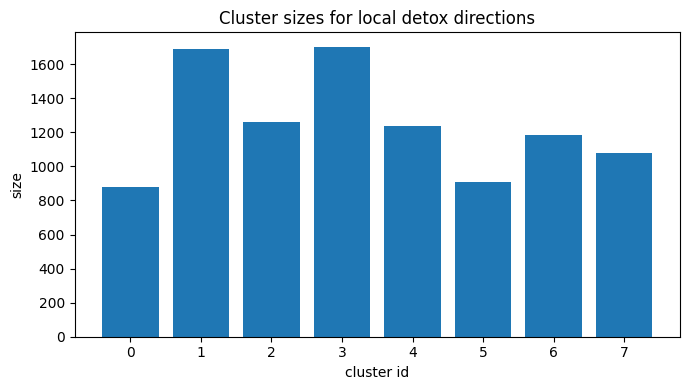

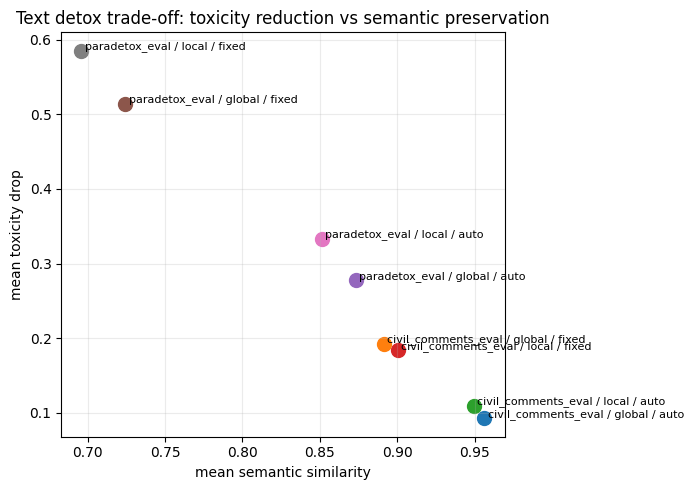

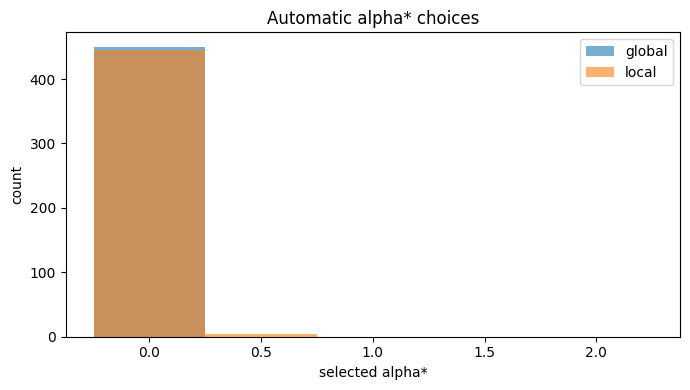

Saved artifacts to: runs/20260405_205719_week12_text_detox_steering

Summary:


,source,mode,selection,toxicity_before,toxicity_after,toxicity_drop,semantic_similarity,target_similarity,surface_penalty,objective,accept_rate,mean_alpha
0,civil_comments_eval,global,auto,0.427433,0.334747,0.092685,0.956304,0.956304,0.051227,0.603661,0.036667,0.000000
1,civil_comments_eval,global,fixed,0.427433,0.235089,0.192343,0.891178,0.598424,0.076482,0.495739,0.036667,1.000000
2,civil_comments_eval,local,auto,0.427433,0.318176,0.109257,0.949799,0.949916,0.054833,0.605418,0.033333,0.001667
3,civil_comments_eval,local,fixed,0.427433,0.243877,0.183556,0.900449,0.604278,0.075719,0.497068,0.033333,1.000000
4,paradetox_eval,global,auto,0.912118,0.634608,0.277510,0.873149,0.873149,0.085991,0.616719,0.013333,0.000000
5,paradetox_eval,global,fixed,0.912118,0.398181,0.513937,0.724426,0.498846,0.172717,0.526945,0.013333,1.000000
6,paradetox_eval,local,auto,0.912118,0.578958,0.333160,0.851176,0.851672,0.170710,0.618950,0.026667,0.013333
7,paradetox_eval,local,fixed,0.912118,0.327135,0.584984,0.695963,0.487609,0.296672,0.534565,0.026667,1.000000



Preview:


,source,mode,sample_id,alpha,toxicity_before,toxicity_after,toxicity_drop,semantic_similarity,target_similarity,input_text,selected_text,reference_text
0,civil_comments_eval,global,civil_eval_00065,0.0,0.359838,0.359838,2.086163e-07,1.0,1.0,Nice win Leafs. Pretty good night for Canadian...,Nice win Leafs. Pretty good night for Canadian...,nan
1,paradetox_eval,global,paradetox_00018,0.0,0.837655,0.837655,5.960464e-08,1.0,1.0,as always he is clueless and lunatic .,as always he is clueless and lunatic .,as always he is clueless and unstable.
2,civil_comments_eval,local,civil_eval_00195,0.0,0.001950,0.001950,1.396984e-09,1.0,1.0,I know it's an opinion piece but have journali...,I know it's an opinion piece but have journali...,nan
3,civil_comments_eval,global,civil_eval_00004,0.0,0.681477,0.681477,0.000000e+00,1.0,1.0,Let's see if these donkeys will retire and liv...,Let's see if these donkeys will retire and liv...,nan
4,civil_comments_eval,global,civil_eval_00100,0.0,0.470605,0.470605,0.000000e+00,1.0,1.0,Sheep meat is the most delicious meat I've eve...,Sheep meat is the most delicious meat I've eve...,nan
5,paradetox_eval,global,paradetox_00038,0.0,0.955526,0.955526,0.000000e+00,1.0,1.0,do you have evidence for this crock of shit ?,do you have evidence for this crock of shit ?,do you have evidence for this?
6,paradetox_eval,global,paradetox_00083,0.0,0.994523,0.994523,0.000000e+00,1.0,1.0,holy fuck its beast from the 46 s series beaut...,holy fuck its beast from the 46 s series beaut...,oh my god its beast from the 46 s series beaut...
7,paradetox_eval,global,paradetox_00119,0.0,0.988898,0.988898,0.000000e+00,1.0,1.0,"hi everyone , i 'm dyeing my hair right now an...","hi everyone , i 'm dyeing my hair right now an...","hi everyone , i 'm dyeing my hair right now an..."
8,paradetox_eval,global,paradetox_00103,0.0,0.909506,0.909506,0.000000e+00,1.0,1.0,"i don 't , but i also don 't give a shit if i ...","i don 't , but i also don 't give a shit if i ...","I don't, but also I don't give , if I like a p..."
9,civil_comments_eval,local,civil_eval_00078,0.0,0.037977,0.037977,-3.725290e-08,1.0,1.0,"I'm afraid you are misinformed. Additionally, ...","I'm afraid you are misinformed. Additionally, ...",nan


In [31]:

# ------------------------ main ------------------------
seed_everything(cfg["seed"])
device = get_device(cfg["device"])
run_dir = make_run_dir(cfg)
print("device:", device)
print("run_dir:", run_dir)
save_json(run_dir / "config.json", cfg)

# 1) data
train_df, civil_eval_df, civil_info = load_civil_comments_frames(cfg)
paradetox_eval_df = load_paradetox_eval_frame(cfg)

eval_parts = [civil_eval_df]
if len(paradetox_eval_df) > 0:
    eval_parts.append(paradetox_eval_df)
eval_df = pd.concat(eval_parts, axis=0, ignore_index=True)

print("train_df:", train_df.shape)
print(train_df.head(3))
print("eval_df by source:")
display(eval_df.groupby("source").size().rename("n").reset_index())

# 2) models
encoder = load_sentence_encoder(cfg["models"]["sentence_encoder_name"], device=device)
toxicity_scorer = load_toxicity_scorer(cfg["models"]["toxicity_model_name"], device=device)
rewriter = load_rewriter(cfg["models"]["rewriter_model_name"], device=device)

fluency_bundle = None
if cfg["fluency"]["enabled"]:
    tok, lm = load_fluency_lm(cfg["models"]["fluency_model_name"], device=device)
    fluency_bundle = (tok, lm, device)

# 3) train embeddings + directions
x_train = encode_texts(encoder, train_df["text"].tolist(), batch_size=cfg["generation"]["batch_size"])
y_train = train_df["label"].to_numpy(dtype=np.int64)

global_dirs = fit_global_directions(x_train, y_train, seed=cfg["seed"])
kmeans, local_dirs, cluster_stats = fit_local_directions(
    x_train=x_train,
    y_train=y_train,
    global_dirs=global_dirs,
    num_clusters=cfg["steering"]["num_clusters"],
    min_cluster_class_count=cfg["steering"]["min_cluster_class_count"],
    seed=cfg["seed"],
)
cluster_stats.to_csv(run_dir / "cluster_stats.csv", index=False)

# 4) eval: global vs local
all_by_alpha = []
all_compare = []
direction_key = cfg["steering"]["direction_key"]

for mode in ["global", "local"]:
    by_alpha_df, compare_df = run_eval_loop(
        eval_df=eval_df,
        mode=mode,
        direction_key=direction_key,
        encoder=encoder,
        toxicity_scorer=toxicity_scorer,
        rewriter=rewriter,
        kmeans=kmeans,
        global_dirs=global_dirs,
        local_dirs=local_dirs,
        cfg=cfg,
        fluency_bundle=fluency_bundle,
    )
    all_by_alpha.append(by_alpha_df)
    all_compare.append(compare_df)

results_by_alpha = pd.concat(all_by_alpha, axis=0, ignore_index=True)
results_compare = pd.concat(all_compare, axis=0, ignore_index=True)
summary_df = summarize_compare(results_compare)
preview_df = build_preview(results_compare, top_k=cfg["preview"]["top_k"])

results_by_alpha.to_csv(run_dir / "results_text_detox_by_alpha.csv", index=False)
results_compare.to_csv(run_dir / "results_text_detox_compare.csv", index=False)
summary_df.to_csv(run_dir / "results_text_detox_summary.csv", index=False)
preview_df.to_csv(run_dir / "preview_text_detox.csv", index=False)

# 5) plots + memo
plot_cluster_sizes(cluster_stats, run_dir / "plots" / "cluster_sizes.png")
plot_tradeoff(summary_df, run_dir / "plots" / "tradeoff_toxicity_vs_similarity.png")
plot_alpha_star(results_compare, run_dir / "plots" / "alpha_star_hist.png")
write_memo(
    out_path=run_dir / "memo_text_detox.md",
    cfg=cfg,
    civil_info=civil_info,
    global_dirs=global_dirs,
    cluster_stats=cluster_stats,
    summary_df=summary_df,
)

print("Saved artifacts to:", run_dir)
print("\nSummary:")
display(summary_df)
print("\nPreview:")
display(preview_df.head(10))


In [32]:
from datasets import load_dataset

ds_all = load_dataset("s-nlp/paradetox")
print(ds_all)

split_name = "train" if "train" in ds_all else list(ds_all.keys())[0]
ds = ds_all[split_name]

print("columns:", ds.column_names)
print(ds[0])

DatasetDict({
    train: Dataset({
        features: ['en_toxic_comment', 'en_neutral_comment'],
        num_rows: 19744
    })
})
columns: ['en_toxic_comment', 'en_neutral_comment']
{'en_toxic_comment': 'he had steel balls too !', 'en_neutral_comment': 'he was brave too!'}



## Notes / practical knobs

- If the rewriter is too slow, reduce `eval_max_rows`, `paradetox_eval_max_rows`, or `num_return_sequences`.
- If the rewrite quality is weak, try a stronger rewriter or richer prompts.
- If the toxicity scorer is noisy, tighten the train thresholds (`toxic_min`, `clean_max`) so the learned direction is cleaner.
- If local clusters are unstable, lower `num_clusters` or raise `train_max_rows`.
- If you want a stricter detox policy, raise `min_toxicity_drop`; if you want stronger semantic preservation, raise `min_semantic_similarity`.
- The notebook is designed around **detoxification** only. We learn a direction from **toxic -> non-toxic** and never optimize generation toward more toxic outputs.


In [36]:
!zip -r output.zip /kaggle/working

updating: kaggle/working/ (stored 0%)
updating: kaggle/working/runs/ (stored 0%)
updating: kaggle/working/runs/20260405_203251_week12_text_detox_steering/ (stored 0%)
updating: kaggle/working/runs/20260405_203251_week12_text_detox_steering/plots/ (stored 0%)
updating: kaggle/working/runs/20260405_203251_week12_text_detox_steering/config.json (deflated 59%)
updating: kaggle/working/runs/20260405_205719_week12_text_detox_steering/ (stored 0%)
updating: kaggle/working/runs/20260405_205719_week12_text_detox_steering/plots/ (stored 0%)
updating: kaggle/working/runs/20260405_205719_week12_text_detox_steering/plots/tradeoff_toxicity_vs_similarity.png (deflated 17%)
updating: kaggle/working/runs/20260405_205719_week12_text_detox_steering/plots/alpha_star_hist.png (deflated 24%)
updating: kaggle/working/runs/20260405_205719_week12_text_detox_steering/plots/cluster_sizes.png (deflated 24%)
updating: kaggle/working/runs/20260405_205719_week12_text_detox_steering/memo_text_detox.md (deflated 61%)


In [37]:
!pwd
!ls -lh
!find /kaggle -maxdepth 2 -name "output.zip"

/kaggle/working
total 676K
-rw-r--r-- 1 root root 671K Apr  5 22:50 output.zip
drwxr-xr-x 5 root root 4.0K Apr  5 20:57 runs
/kaggle/working/output.zip


In [38]:
!cd /kaggle/working && zip -r /kaggle/working/output.zip runs

  adding: runs/ (stored 0%)
  adding: runs/20260405_203251_week12_text_detox_steering/ (stored 0%)
  adding: runs/20260405_203251_week12_text_detox_steering/plots/ (stored 0%)
  adding: runs/20260405_203251_week12_text_detox_steering/config.json (deflated 59%)
  adding: runs/20260405_205719_week12_text_detox_steering/ (stored 0%)
  adding: runs/20260405_205719_week12_text_detox_steering/plots/ (stored 0%)
  adding: runs/20260405_205719_week12_text_detox_steering/plots/tradeoff_toxicity_vs_similarity.png (deflated 17%)
  adding: runs/20260405_205719_week12_text_detox_steering/plots/alpha_star_hist.png (deflated 24%)
  adding: runs/20260405_205719_week12_text_detox_steering/plots/cluster_sizes.png (deflated 24%)
  adding: runs/20260405_205719_week12_text_detox_steering/memo_text_detox.md (deflated 61%)
  adding: runs/20260405_205719_week12_text_detox_steering/results_text_detox_summary.csv (deflated 57%)
  adding: runs/20260405_205719_week12_text_detox_steering/results_text_detox_by_alph

In [39]:
!zip -r /kaggle/working/output.zip /kaggle/working/runs

updating: kaggle/working/runs/ (stored 0%)
updating: kaggle/working/runs/20260405_203251_week12_text_detox_steering/ (stored 0%)
updating: kaggle/working/runs/20260405_203251_week12_text_detox_steering/plots/ (stored 0%)
updating: kaggle/working/runs/20260405_203251_week12_text_detox_steering/config.json (deflated 59%)
updating: kaggle/working/runs/20260405_205719_week12_text_detox_steering/ (stored 0%)
updating: kaggle/working/runs/20260405_205719_week12_text_detox_steering/plots/ (stored 0%)
updating: kaggle/working/runs/20260405_205719_week12_text_detox_steering/plots/tradeoff_toxicity_vs_similarity.png (deflated 17%)
updating: kaggle/working/runs/20260405_205719_week12_text_detox_steering/plots/alpha_star_hist.png (deflated 24%)
updating: kaggle/working/runs/20260405_205719_week12_text_detox_steering/plots/cluster_sizes.png (deflated 24%)
updating: kaggle/working/runs/20260405_205719_week12_text_detox_steering/memo_text_detox.md (deflated 61%)
updating: kaggle/working/runs/20260405

In [40]:
from IPython.display import FileLink
FileLink('/kaggle/working/output.zip')

/kaggle/working/output.zip

In [41]:
import os

path = "/kaggle/working/output.zip"
print("exists:", os.path.exists(path))
print("size:", os.path.getsize(path), "bytes")

exists: True
size: 1361815 bytes


In [42]:
import os
import zipfile

zip_path = "/kaggle/working/output.zip"
folder_to_zip = "/kaggle/working/runs"

if os.path.exists(zip_path):
    os.remove(zip_path)

with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zf:
    for root, dirs, files in os.walk(folder_to_zip):
        for file in files:
            full_path = os.path.join(root, file)
            arcname = os.path.relpath(full_path, "/kaggle/working")
            zf.write(full_path, arcname)

print("created:", zip_path)
print("exists:", os.path.exists(zip_path))
print("size:", os.path.getsize(zip_path), "bytes")

created: /kaggle/working/output.zip
exists: True
size: 671043 bytes
